In [2]:
import xarray as xr
import matplotlib.pyplot as plt 


In [ ]:
file_name = "/home/karengarcia/downloads-karengarcia/MERRA-2/tavg3_3d_asm_Nv/MERRA2_400.tavg3_3d_asm_Nv.20140606.nc4"
file = xr.open_dataset(file_name)
display(file["QL"])
display(file["QI"])

<xarray.DataArray 'QL' (time: 8, lev: 72, lat: 361, lon: 576)> Size: 479MB
[119771136 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
  * time     (time) datetime64[ns] 64B 2014-06-06T01:30:00 ... 2014-06-06T22:...
Attributes:
    long_name:       mass_fraction_of_cloud_liquid_water
    units:           kg kg-1
    fmissing_value:  1000000000000000.0
    standard_name:   mass_fraction_of_cloud_liquid_water
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]

<xarray.DataArray 'QI' (time: 8, lev: 72, lat: 361, lon: 576)> Size: 479MB
[119771136 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
  * time     (time) datetime64[ns] 64B 2014-06-06T01:30:00 ... 2014-06-06T22:...
Attributes:
    long_name:       mass_fraction_of_cloud_ice_water
    units:           kg kg-1
    fmissing_value:  1000000000000000.0
    standard_name:   mass_fraction_of_cloud_ice_water
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]

In [ ]:
temp = (file['T']).isel(time=2).sel(lat = 0, lon =0, method='nearest').sel(lev=slice(33,48))
pressure = (file['PL']).isel(time=2).sel(lat = 0, lon =0, method='nearest').sel(lev=slice(33,48))
display(temp)
display(pressure.values/100)


<xarray.DataArray 'T' (lev: 15)> Size: 60B
[15 values with dtype=float32]
Coordinates:
    lon      float64 8B -5.92e-13
    lat      float64 8B -1.798e-13
  * lev      (lev) float64 120B 34.0 35.0 36.0 37.0 38.0 ... 45.0 46.0 47.0 48.0
    time     datetime64[ns] 8B 2014-06-06T07:30:00
Attributes:
    long_name:       air_temperature
    units:           K
    fmissing_value:  1000000000000000.0
    standard_name:   air_temperature
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]

array([ 52.01592 ,  61.495644,  72.55785 ,  85.439026, 100.514366,
       118.25001 , 139.115   , 163.66156 , 192.58441 , 226.73125 ,
       267.05106 , 313.89963 , 357.9289  , 395.9711  , 434.02332 ],
      dtype=float32)

(400.0, 30.0)

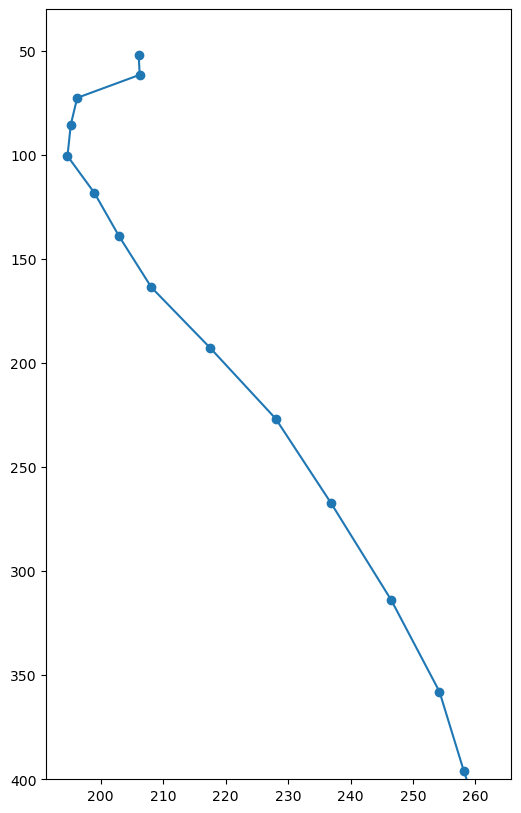

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(6, 10))
ax.plot(temp.values, pressure.values/100, "-o")
ax.set_ylim([400,30])

In [10]:
import numpy as np
levels = np.arange(0, 10, 1)
print(levels)


[0 1 2 3 4 5 6 7 8 9]


In [7]:

precip_file = "/home/karengarcia/downloads-karengarcia/MERRA-2/statD_2d_slv_Nx/MERRA2_400.statD_2d_slv_Nx.20140606.nc4"
precip = xr.open_dataset(precip_file) 
display(precip["TPRECMAX"].min())

<xarray.DataArray 'TPRECMAX' ()> Size: 4B
array(0., dtype=float32)

In [6]:
8 /86400

9.259259259259259e-05

In [28]:
ice_precip = "/home/karengarcia/downloads-karengarcia/MERRA-2/tavg3_3d_mst_Ne/MERRA2_400.tavg3_3d_mst_Ne.20140606.nc4"
precip = xr.open_dataset(ice_precip)
display(precip)

<xarray.Dataset> Size: 3GB
Dimensions:  (lon: 576, lat: 361, lev: 73, time: 8)
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lev      (lev) float64 584B 0.0 1.0 2.0 3.0 4.0 ... 68.0 69.0 70.0 71.0 72.0
  * time     (time) datetime64[ns] 64B 2014-06-06T01:30:00 ... 2014-06-06T22:...
Data variables:
    CMFMC    (time, lev, lat, lon) float32 486MB ...
    PFICU    (time, lev, lat, lon) float32 486MB ...
    PFILSAN  (time, lev, lat, lon) float32 486MB ...
    PFLCU    (time, lev, lat, lon) float32 486MB ...
    PFLLSAN  (time, lev, lat, lon) float32 486MB ...
    PLE      (time, lev, lat, lon) float32 486MB ...
Attributes: (12/30)
    History:                           Original file generated: Mon Dec 22 13...
    Comment:                           GMAO filename: d5124_m2_jan10.tavg3_3d...
    Filename:                          MERRA2_400.tavg3_3d_mst_Ne.20140606.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/JRUZ3SJ3ZJ72
    RangeBeginningDate:                2014-06-06
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2014-06-06
    RangeEndingTime:                   23:59:59.000000

In [38]:
precip_file = "/home/karengarcia/downloads-karengarcia/MERRA-2/tavg3_3d_mst_Np/MERRA2_400.tavg3_3d_mst_Np.20140606.nc4"
precip = (xr.open_dataset(precip_file))
display(precip)

# # 1. Calculate a 3-hour rolling mean
# # center=True ensures the average of [00:30, 01:30, 02:30] is assigned to 01:30
# ds_rolling = test.rolling(time=3, center=True).mean()

# # 2. Slice the result to pick only the 3-hour centers
# # This selects every 3rd hour, starting from the first valid center (index 1)
# ds_3hr_final = ds_rolling.isel(time=slice(1, None, 3))

# print(ds_3hr_final.time.values)

<xarray.Dataset> Size: 3GB
Dimensions:     (lon: 576, lat: 361, lev: 42, time: 8)
Coordinates:
  * lon         (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.1 178.8 179.4
  * lat         (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 89.0 89.5 90.0
  * lev         (lev) float64 336B 1e+03 975.0 950.0 925.0 ... 0.5 0.4 0.3 0.1
  * time        (time) datetime64[ns] 64B 2014-06-06T01:30:00 ... 2014-06-06T...
Data variables:
    CMFMC       (time, lev, lat, lon) float32 279MB ...
    DQRCU       (time, lev, lat, lon) float32 279MB ...
    DQRLSAN     (time, lev, lat, lon) float32 279MB ...
    PFICU       (time, lev, lat, lon) float32 279MB ...
    PFILSAN     (time, lev, lat, lon) float32 279MB ...
    PFLCU       (time, lev, lat, lon) float32 279MB ...
    PFLLSAN     (time, lev, lat, lon) float32 279MB ...
    REEVAPCN    (time, lev, lat, lon) float32 279MB ...
    REEVAPLSAN  (time, lev, lat, lon) float32 279MB ...
Attributes: (12/30)
    History:                           Original file generated: Mon Dec 22 13...
    Comment:                           GMAO filename: d5124_m2_jan10.tavg3_3d...
    Filename:                          MERRA2_400.tavg3_3d_mst_Np.20140606.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/0TUFO90Q2PMS
    RangeBeginningDate:                2014-06-06
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2014-06-06
    RangeEndingTime:                   23:59:59.000000